In [84]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import datetime as datetime

In [85]:
file_path = 'data/F1_sample_data_with_random_consultoras.csv' 
data = pd.read_csv(file_path)
print(data)

        CODEBELISTA  ANIOCAMPANA CODPAIS  CODPRODUCTOSAP      DESCATEGORIA  \
0          49958455       202302      PE       210100816        MAQUILLAJE   
1          50038750       202302      PE       200095170  CUIDADO PERSONAL   
2          26877393       202302      PE       200105125  CUIDADO PERSONAL   
3          48742556       202302      PE       200097066  CUIDADO PERSONAL   
4          49769164       202302      PE       200078924  CUIDADO PERSONAL   
...             ...          ...     ...             ...               ...   
168055     45658163       202418      PE       200105017        FRAGANCIAS   
168056     52166489       202418      PE       210103140            LENTES   
168057     52683025       202418      PE       200095931        FRAGANCIAS   
168058     52683025       202418      PE       200114054        MAQUILLAJE   
168059     52204089       202501      PE       210105381      COMPLEMENTOS   

       DESMARCA  PRECIOOFERTA FECHAPROCESO  
0         ESIKA   

In [86]:
df = pd.read_csv(file_path)
# df['CODEBELISTA'].value_counts()
df['CODEBELISTA'].nunique()

2097

In [87]:
data['FECHAPROCESO'] = pd.to_datetime(data['FECHAPROCESO'])

# Calculate Recency: Normalize such that 10 is the latest and 1 is the oldest for each consultora
latest_date = data['FECHAPROCESO'].max()
oldest_date = data['FECHAPROCESO'].min()

# For each consultora, calculate Recency and normalize it between 1 and 10 (10 is the latest and 1 is the oldest)
data['Recency'] = data.groupby('CODEBELISTA')['FECHAPROCESO'].transform(
    lambda x: 1 + 9 * ((latest_date - x).dt.days) / ((latest_date - oldest_date).days)
)

# Frequency by CODEBELISTA
frequency = data.groupby('CODEBELISTA').size().reset_index(name='Frequency')

# Normalize Frequency: Scale between 1 and 10
frequency['Frequency'] = 1 + 9 * (frequency['Frequency'] - frequency['Frequency'].min()) / (frequency['Frequency'].max() - frequency['Frequency'].min())

# Aggregate other columns (take the first value per CODEBELISTA or use other aggregation methods)
agg_data = data.groupby('CODEBELISTA').agg(
    ANIOCAMPANA=('ANIOCAMPANA', 'first'),
    CODPRODUCTOSAP=('CODPRODUCTOSAP', 'first'),
    DESCATEGORIA=('DESCATEGORIA', 'first'),
    DESMARCA=('DESMARCA', 'first'),
    PRECIOOFERTA=('PRECIOOFERTA', 'first')
).reset_index()

# Merge Frequency and Recency on CODEBELISTA
rf_data = pd.merge(frequency, data[['CODEBELISTA', 'Recency']].drop_duplicates(), on='CODEBELISTA')
rf_data = pd.merge(rf_data, agg_data, on='CODEBELISTA')

# Final DataFrame
print(rf_data.head())

   CODEBELISTA  Frequency   Recency  ANIOCAMPANA  CODPRODUCTOSAP  \
0       227323   1.312655  7.464619       202310       200103726   
1       227323   1.312655  7.981308       202310       200103726   
2       227323   1.312655  9.567423       202310       200103726   
3      1058614   2.596774  7.440587       202310       210097089   
4      1058614   2.596774  7.152203       202310       210097089   

       DESCATEGORIA DESMARCA  PRECIOOFERTA  
0        MAQUILLAJE    ESIKA          26.9  
1        MAQUILLAJE    ESIKA          26.9  
2        MAQUILLAJE    ESIKA          26.9  
3  CUIDADO PERSONAL     LBEL          13.9  
4  CUIDADO PERSONAL     LBEL          13.9  


#### Count the number of products in each category within each combination of Recency and Frequency bins

In [88]:
# Add a 'Category' column (if not already added)
rf_data['Category'] = rf_data['DESCATEGORIA']

# Calculate Combined Score
alpha, beta = 0.5, 0.5
rf_data['Combined_Score'] = alpha * rf_data['Frequency'] + beta * rf_data['Recency']

# Define bins for Recency and Frequency
bins_recency = np.arange(0, 11, 1)  # 10 bins for Recency
bins_frequency = np.arange(0, 11, 1)  # 10 bins for Frequency

# Create binned columns
rf_data['Recency_bins'] = pd.cut(rf_data['Recency'], bins=bins_recency, include_lowest=True)
rf_data['Frequency_bins'] = pd.cut(rf_data['Frequency'], bins=bins_frequency, include_lowest=True)

# Count the number of products in each category within each combination of Recency and Frequency bins
category_counts = rf_data.groupby(['Recency_bins', 'Frequency_bins', 'Category']).size().reset_index(name='Product_Count')

# Save the category counts to a CSV file
category_counts.to_csv('category_counts.csv', index=False)

cc_df = pd.read_csv('category_counts.csv')

# Print to confirm the reload worked
print(cc_df.head())


    Recency_bins Frequency_bins               Category  Product_Count
0  (-0.001, 1.0]  (-0.001, 1.0]  ACCESORIOS COSMETICOS              0
1  (-0.001, 1.0]  (-0.001, 1.0]             BIJOUTERIE              0
2  (-0.001, 1.0]  (-0.001, 1.0]           COMPLEMENTOS              0
3  (-0.001, 1.0]  (-0.001, 1.0]       CUIDADO PERSONAL              0
4  (-0.001, 1.0]  (-0.001, 1.0]             FRAGANCIAS              0


C:\Users\athar\AppData\Local\Temp\ipykernel_22244\3775224079.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_counts = rf_data.groupby(['Recency_bins', 'Frequency_bins', 'Category']).size().reset_index(name='Product_Count')


In [89]:
cc_df.head

<bound method NDFrame.head of        Recency_bins Frequency_bins               Category  Product_Count
0     (-0.001, 1.0]  (-0.001, 1.0]  ACCESORIOS COSMETICOS              0
1     (-0.001, 1.0]  (-0.001, 1.0]             BIJOUTERIE              0
2     (-0.001, 1.0]  (-0.001, 1.0]           COMPLEMENTOS              0
3     (-0.001, 1.0]  (-0.001, 1.0]       CUIDADO PERSONAL              0
4     (-0.001, 1.0]  (-0.001, 1.0]             FRAGANCIAS              0
...             ...            ...                    ...            ...
1395    (9.0, 10.0]    (9.0, 10.0]     PROMOCION USUARIOS              0
1396    (9.0, 10.0]    (9.0, 10.0]                RELOJES              0
1397    (9.0, 10.0]    (9.0, 10.0]   TRATAMIENTO CORPORAL              0
1398    (9.0, 10.0]    (9.0, 10.0]     TRATAMIENTO FACIAL              0
1399    (9.0, 10.0]    (9.0, 10.0]                 VARIOS              0

[1400 rows x 4 columns]>

#### A graph showing the aggregated product counts for each frequency bin.

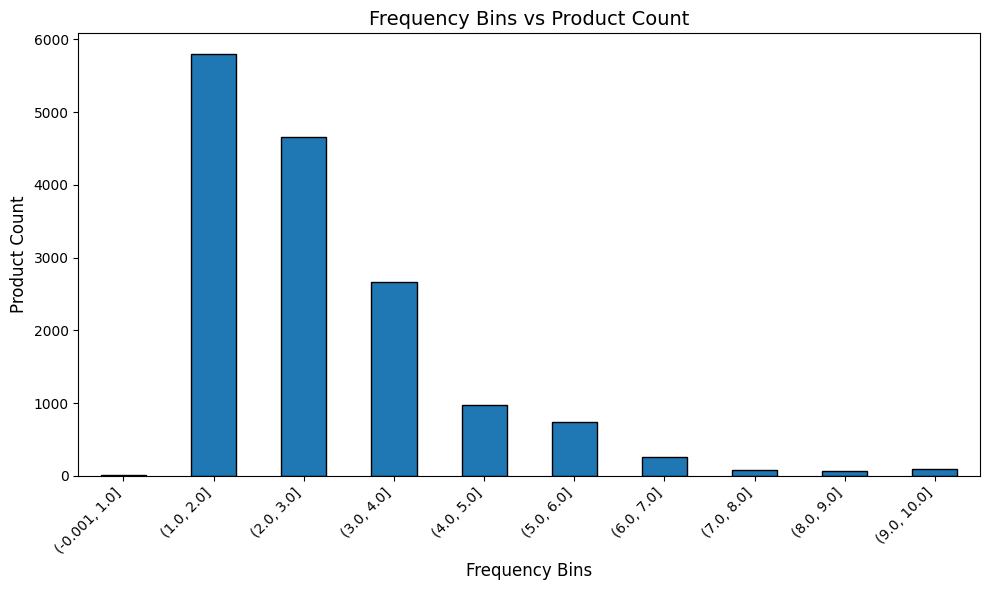

In [90]:
# Aggregate the product counts by Frequency_bins
frequency_bins_agg = cc_df.groupby('Frequency_bins')['Product_Count'].sum()

# Plot the Frequency_bins vs Product_Count
plt.figure(figsize=(10, 6))
frequency_bins_agg.plot(kind='bar', edgecolor='black')
plt.title('Frequency Bins vs Product Count', fontsize=14)
plt.xlabel('Frequency Bins', fontsize=12)
plt.ylabel('Product Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### A graph showing the aggregated product counts for each Recency bin.

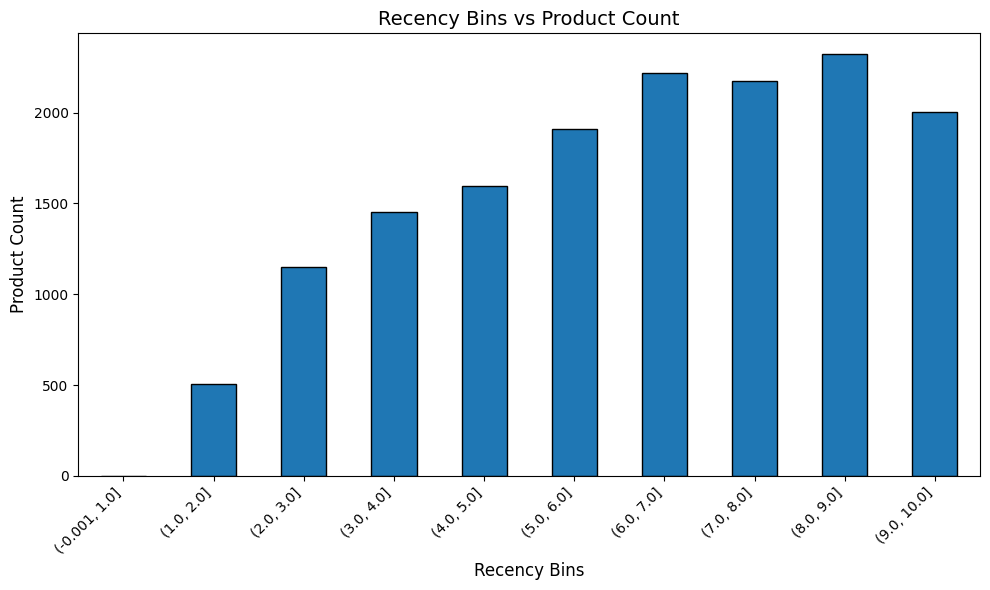

In [91]:
# Aggregate the product counts by Recency_bins
recency_bins_agg = cc_df.groupby('Recency_bins')['Product_Count'].sum()

# Plot the Recency_bins vs Product_Count
plt.figure(figsize=(10, 6))
recency_bins_agg.plot(kind='bar', edgecolor='black')
plt.title('Recency Bins vs Product Count', fontsize=14)
plt.xlabel('Recency Bins', fontsize=12)
plt.ylabel('Product Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### These weights reflect the relative importance of frequency and recency based on their variability, with recency having a slightly higher weight due to its greater entropy.

In [92]:
# Function to calculate entropy
def calculate_entropy(cc_df):
    probabilities = cc_df / cc_df.sum()
    # Filter out zero probabilities to avoid log issues
    probabilities = probabilities[probabilities > 0]
    entropy = -np.sum(probabilities * np.log(probabilities))
    return entropy

# Calculate entropy for Frequency_bins and Recency_bins
frequency_entropy = calculate_entropy(frequency_bins_agg)
recency_entropy = calculate_entropy(recency_bins_agg)

# Calculate weights
total_entropy = frequency_entropy + recency_entropy
alpha = frequency_entropy / total_entropy
beta = recency_entropy / total_entropy

# Display results
print("frequency_entropy: {:.2f}".format(frequency_entropy))
print("recency_entropy: {:.2f}".format(recency_entropy))
print("alpha: {:.2f}".format(alpha))
print("beta: {:.2f}".format(beta))

frequency_entropy: 1.51
recency_entropy: 2.13
alpha: 0.41
beta: 0.59


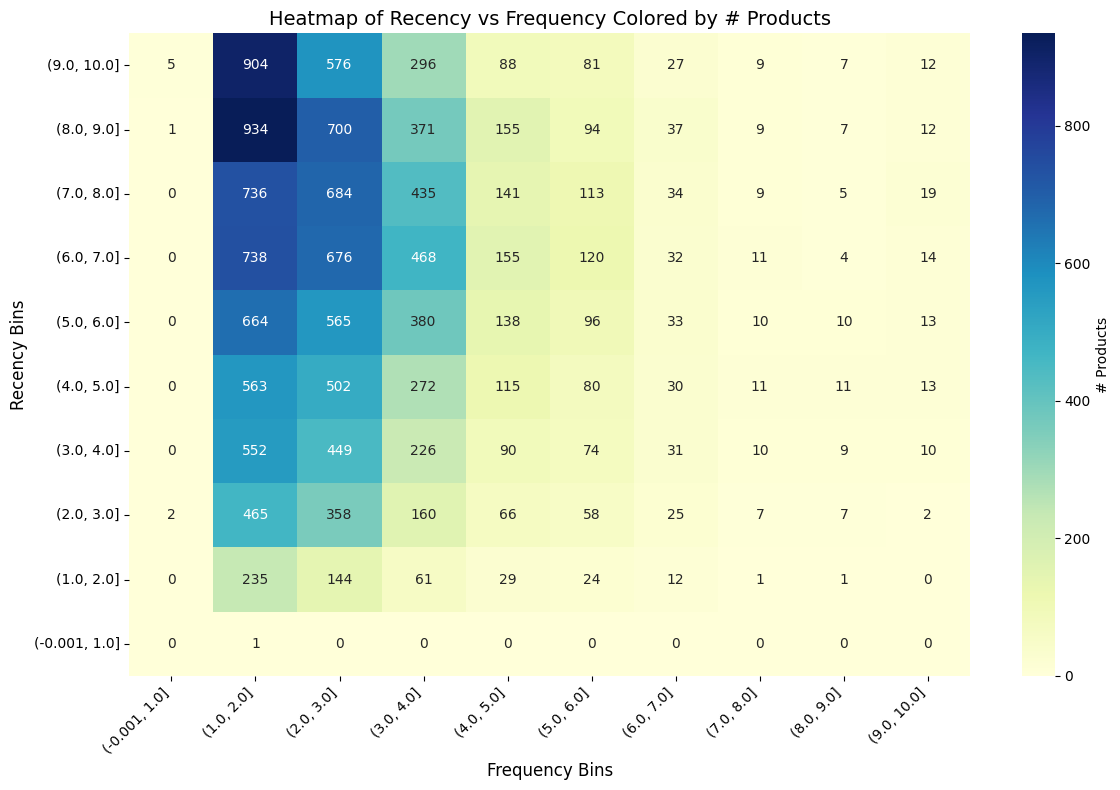

In [93]:
# Pivot the data to create a matrix for heatmap
heatmap_data = cc_df.pivot_table(index='Recency_bins', columns='Frequency_bins', values='Product_Count', aggfunc='sum', fill_value=0)

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': '# Products'})
plt.title('Heatmap of Recency vs Frequency Colored by # Products', fontsize=14)
plt.xlabel('Frequency Bins', fontsize=12)
plt.ylabel('Recency Bins', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Invert the y-axis
plt.gca().invert_yaxis()

# Display the plot
plt.show()

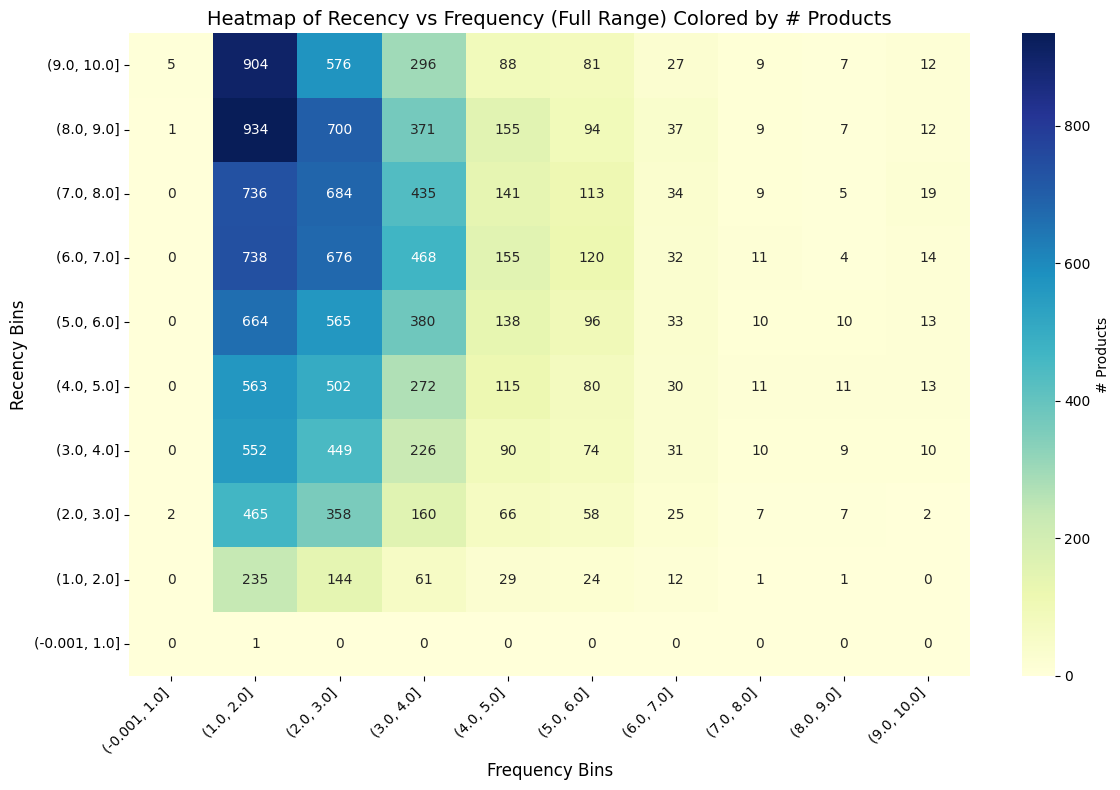

In [94]:
# Create all possible combinations of Recency_bins and Frequency_bins
recency_bins = cc_df['Recency_bins'].unique()
frequency_bins = cc_df['Frequency_bins'].unique()

# Create a full grid of recency and frequency bins
all_combinations = pd.DataFrame([(r, f) for r in recency_bins for f in frequency_bins], columns=['Recency_bins', 'Frequency_bins'])

# Merge with the original data to ensure all combinations are present, filling missing values with 0
full_data = all_combinations.merge(cc_df, on=['Recency_bins', 'Frequency_bins'], how='left').fillna({'Product_Count': 0})

# Pivot the data for the heatmap
full_heatmap_data = full_data.pivot_table(index='Recency_bins', columns='Frequency_bins', values='Product_Count', aggfunc='sum', fill_value=0)

# Plot the updated heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(full_heatmap_data, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': '# Products'})
plt.title('Heatmap of Recency vs Frequency (Full Range) Colored by # Products', fontsize=14)
plt.xlabel('Frequency Bins', fontsize=12)
plt.ylabel('Recency Bins', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

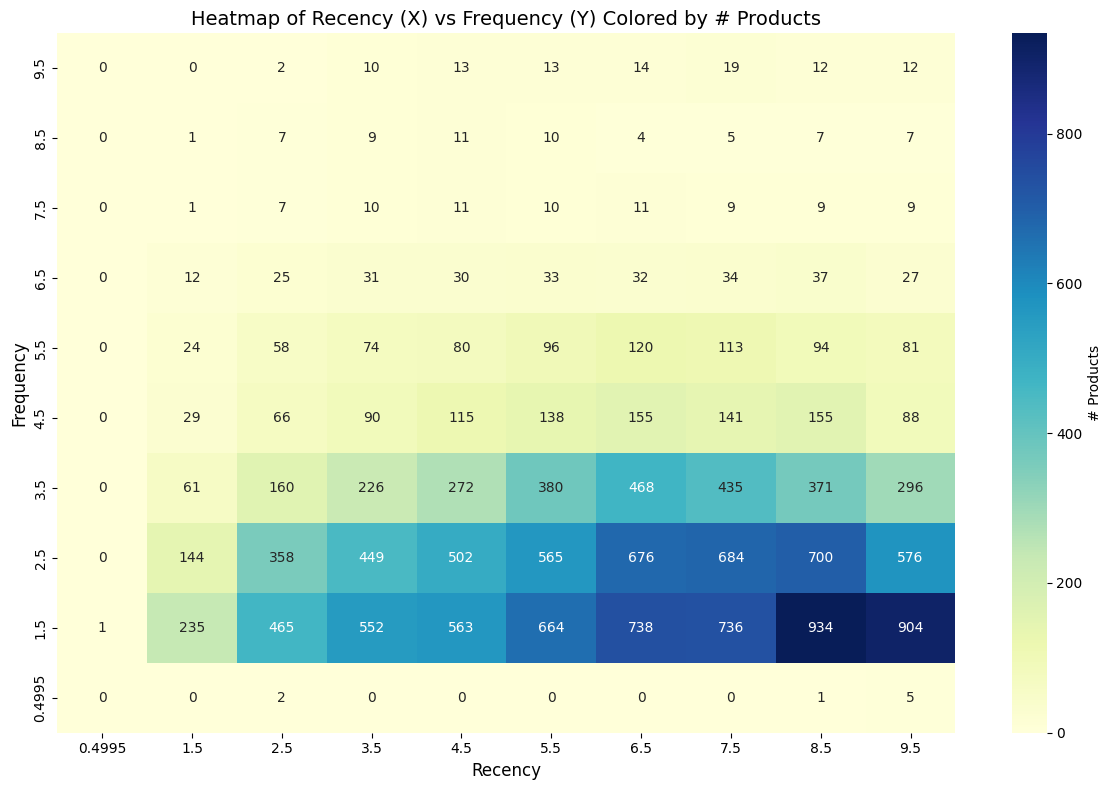

In [95]:
# Convert bins into numeric ranges for better visualization
def extract_bin_edges(bin_labels):
    """
    Extract numeric edges from bin labels (e.g., '(-0.001, 1.0]').
    """
    bin_edges = bin_labels.str.extract(r'\((.*),\s(.*)\]', expand=True).astype(float)
    return bin_edges.mean(axis=1)  # Use the midpoint for plotting

# Add numeric recency and frequency bins for plotting
full_data['Recency_numeric'] = extract_bin_edges(full_data['Recency_bins'])
full_data['Frequency_numeric'] = extract_bin_edges(full_data['Frequency_bins'])

# Create a pivot table with numeric bins
numeric_heatmap_data = full_data.pivot_table(
    index='Frequency_numeric',
    columns='Recency_numeric',
    values='Product_Count',
    aggfunc='sum',
    fill_value=0
)

# Plot the heatmap with numeric axes
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_heatmap_data, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': '# Products'})
plt.title('Heatmap of Recency (X) vs Frequency (Y) Colored by # Products', fontsize=14)
plt.xlabel('Recency', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

In [96]:
print(alpha, beta)

0.4141991429833447 0.5858008570166553


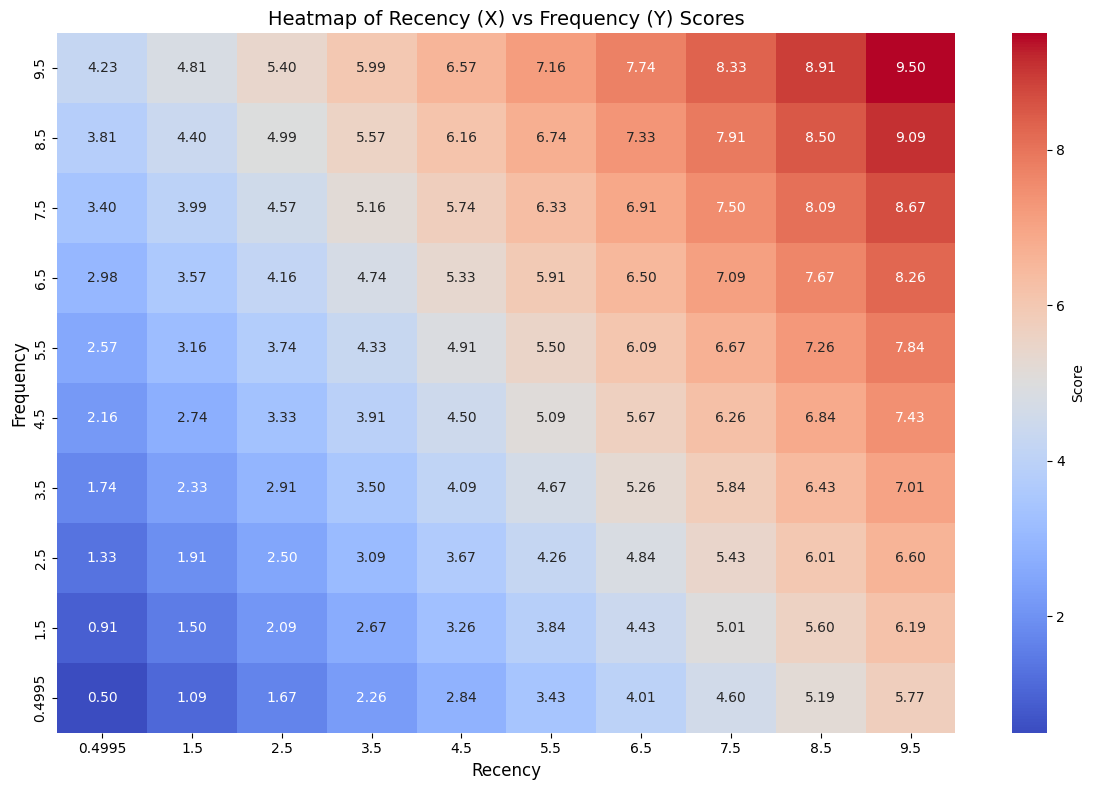

In [97]:
# Compute scores for each square in the heatmap
# Use midpoints of bins as representative values for frequency and recency
full_data['Score'] = (
    alpha * full_data['Frequency_numeric'] +
    beta * full_data['Recency_numeric']
)

# Create a pivot table for scores
score_heatmap_data = full_data.pivot_table(
    index='Frequency_numeric',
    columns='Recency_numeric',
    values='Score',
    aggfunc='mean',
    fill_value=0
)

# Plot the heatmap for scores
plt.figure(figsize=(12, 8))
sns.heatmap(score_heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Score'})
plt.gca().invert_yaxis()  # Invert the y-axis for consistency
plt.title('Heatmap of Recency (X) vs Frequency (Y) Scores', fontsize=14)
plt.xlabel('Recency', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

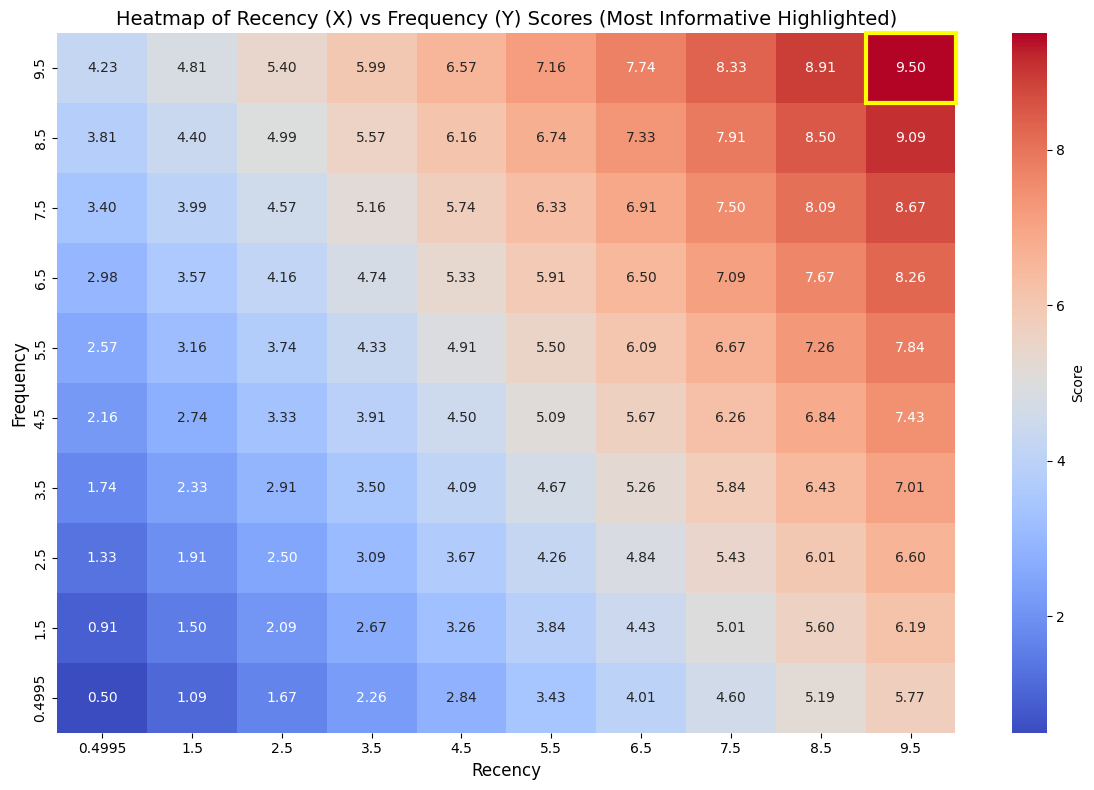

Most Informative Score:  (np.float64(9.5), np.float64(9.5))
Max score value:  9.5


In [98]:
# Identify the square with the maximum score
max_score_row = full_data.loc[full_data['Score'].idxmax()]
most_informative_square = (max_score_row['Recency_numeric'], max_score_row['Frequency_numeric'])
max_score_value = max_score_row['Score']

# Plot the heatmap with the most informative square highlighted
plt.figure(figsize=(12, 8))
ax = sns.heatmap(score_heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Score'})
plt.gca().invert_yaxis()  # Invert the y-axis for consistency

# Highlight the most informative square
ax.add_patch(plt.Rectangle(
    (most_informative_square[0] - score_heatmap_data.columns.min(),
     most_informative_square[1] - score_heatmap_data.index.min()),
    1, 1, fill=False, edgecolor='yellow', lw=3, clip_on=False))

plt.title('Heatmap of Recency (X) vs Frequency (Y) Scores (Most Informative Highlighted)', fontsize=14)
plt.xlabel('Recency', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

print("Most Informative Score: ", most_informative_square)
print("Max score value: ", max_score_value)

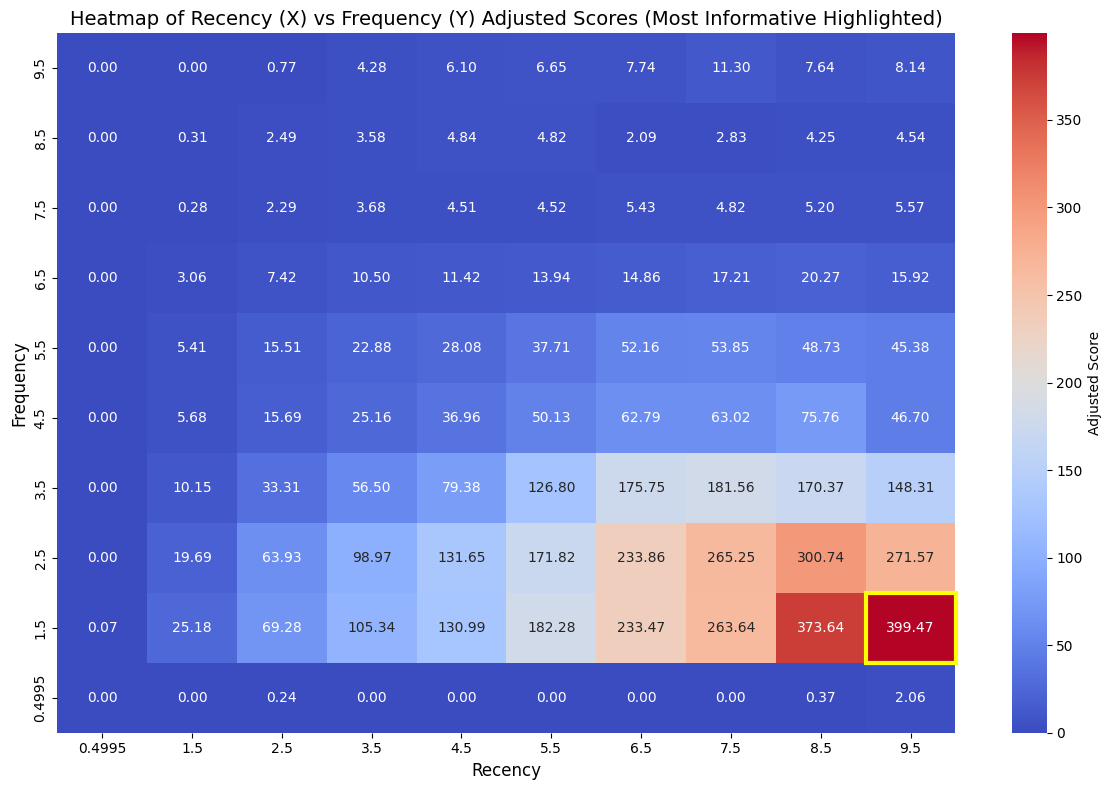

Most Informative Score adjusted:  (np.float64(9.5), np.float64(1.5))
Max adjusted score value:  1571.3473414578436


In [99]:
# Compute the adjusted scores by incorporating the Product Count
full_data['Adjusted_Score'] = full_data['Score'] * full_data['Product_Count']

# Create a pivot table for adjusted scores
adjusted_score_heatmap_data = full_data.pivot_table(
    index='Frequency_numeric',
    columns='Recency_numeric',
    values='Adjusted_Score',
    aggfunc='mean',
    fill_value=0
)

# Identify the square with the highest adjusted score
max_adjusted_score_row = full_data.loc[full_data['Adjusted_Score'].idxmax()]
most_informative_square_adjusted = (max_adjusted_score_row['Recency_numeric'], max_adjusted_score_row['Frequency_numeric'])
max_adjusted_score_value = max_adjusted_score_row['Adjusted_Score']

# Plot the heatmap with adjusted scores and the most informative square highlighted
plt.figure(figsize=(12, 8))
ax = sns.heatmap(adjusted_score_heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Adjusted Score'})
plt.gca().invert_yaxis()  # Invert the y-axis for consistency

# Highlight the most informative square
ax.add_patch(plt.Rectangle(
    (most_informative_square_adjusted[0] - adjusted_score_heatmap_data.columns.min(),
     most_informative_square_adjusted[1] - adjusted_score_heatmap_data.index.min()),
    1, 1, fill=False, edgecolor='yellow', lw=3, clip_on=False))

plt.title('Heatmap of Recency (X) vs Frequency (Y) Adjusted Scores (Most Informative Highlighted)', fontsize=14)
plt.xlabel('Recency', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

print("Most Informative Score adjusted: ", most_informative_square_adjusted)
print("Max adjusted score value: ", max_adjusted_score_value)

In [100]:
print(alpha)

0.4141991429833447


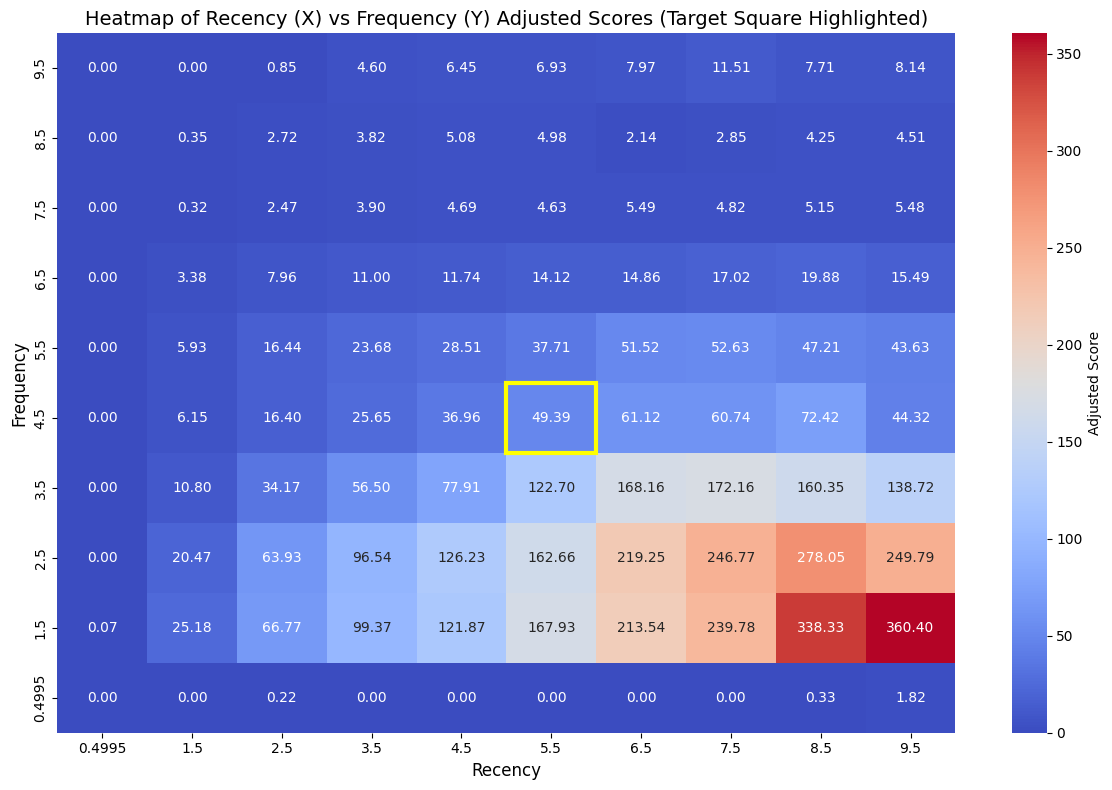

((np.float64(5.5), np.float64(4.5)), np.float64(0.0))

In [74]:
# Calculate the target square based on entropy weights
target_frequency = alpha * 10
target_recency = beta * 10

# Find the square closest to the target values
# The closeness is determined using the Euclidean distance between the actual and target values
closest_row = full_data.loc[
    ((full_data['Frequency_numeric'] - target_frequency)**2 +
     (full_data['Recency_numeric'] - target_recency)**2).idxmin()
]
closest_square = (closest_row['Recency_numeric'], closest_row['Frequency_numeric'])
closest_score_value = closest_row['Adjusted_Score']

# Plot the heatmap with the closest square highlighted
plt.figure(figsize=(12, 8))
ax = sns.heatmap(adjusted_score_heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Adjusted Score'})
plt.gca().invert_yaxis()  # Invert the y-axis for consistency

# Highlight the target square
ax.add_patch(plt.Rectangle(
    (closest_square[0] - adjusted_score_heatmap_data.columns.min(),
     closest_square[1] - adjusted_score_heatmap_data.index.min()),
    1, 1, fill=False, edgecolor='yellow', lw=3, clip_on=False))

plt.title('Heatmap of Recency (X) vs Frequency (Y) Adjusted Scores (Target Square Highlighted)', fontsize=14)
plt.xlabel('Recency', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

closest_square, closest_score_value

#### Heatmap analysis with "Most Informative Square Highlighted"

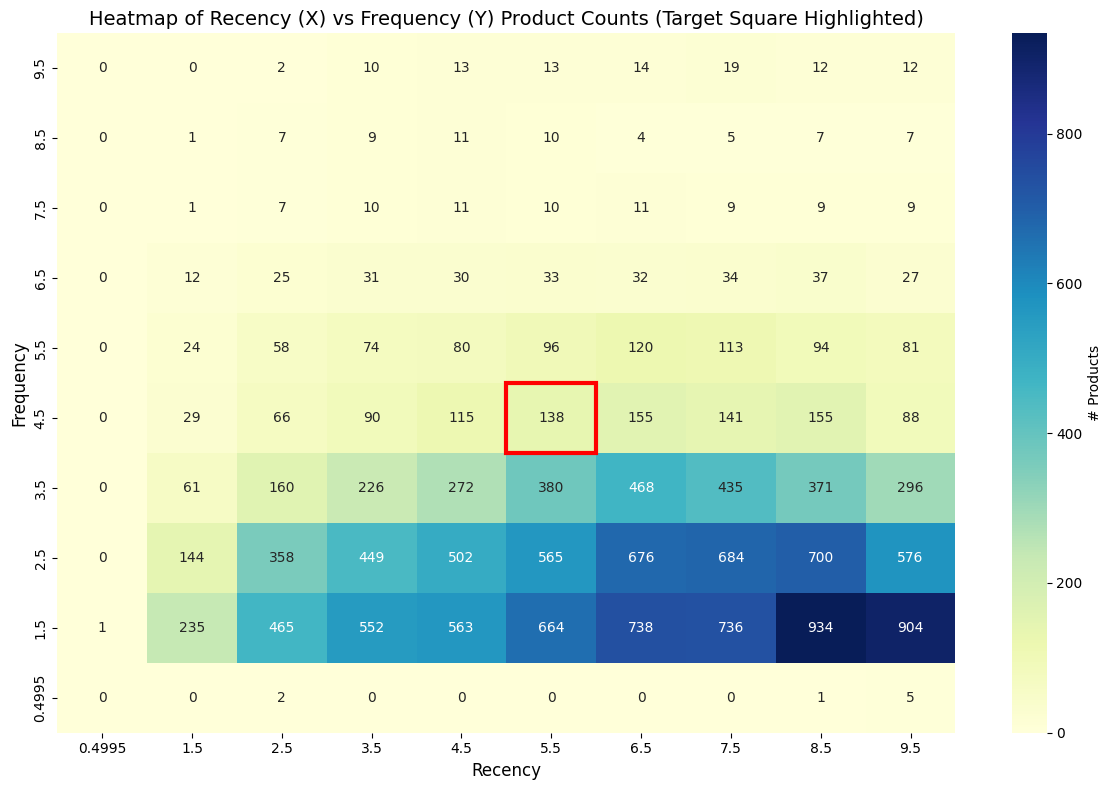

In [75]:
# Create a pivot table for product counts
product_count_heatmap_data = full_data.pivot_table(
    index='Frequency_numeric',
    columns='Recency_numeric',
    values='Product_Count',
    aggfunc='sum',
    fill_value=0
)

# Plot the heatmap for product counts with the target square highlighted
plt.figure(figsize=(12, 8))
ax = sns.heatmap(product_count_heatmap_data, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': '# Products'})
plt.gca().invert_yaxis()  # Invert the y-axis for consistency

# Highlight the target square
ax.add_patch(plt.Rectangle(
    (closest_square[0] - product_count_heatmap_data.columns.min(),
     closest_square[1] - product_count_heatmap_data.index.min()),
    1, 1, fill=False, edgecolor='red', lw=3, clip_on=False))

plt.title('Heatmap of Recency (X) vs Frequency (Y) Product Counts (Target Square Highlighted)', fontsize=14)
plt.xlabel('Recency', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\athar\AppData\Local\Temp\ipykernel_22244\979910015.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = rf_data.groupby(['Frequency_bins', 'Recency_bins'])['PRECIOOFERTA'].sum().unstack()


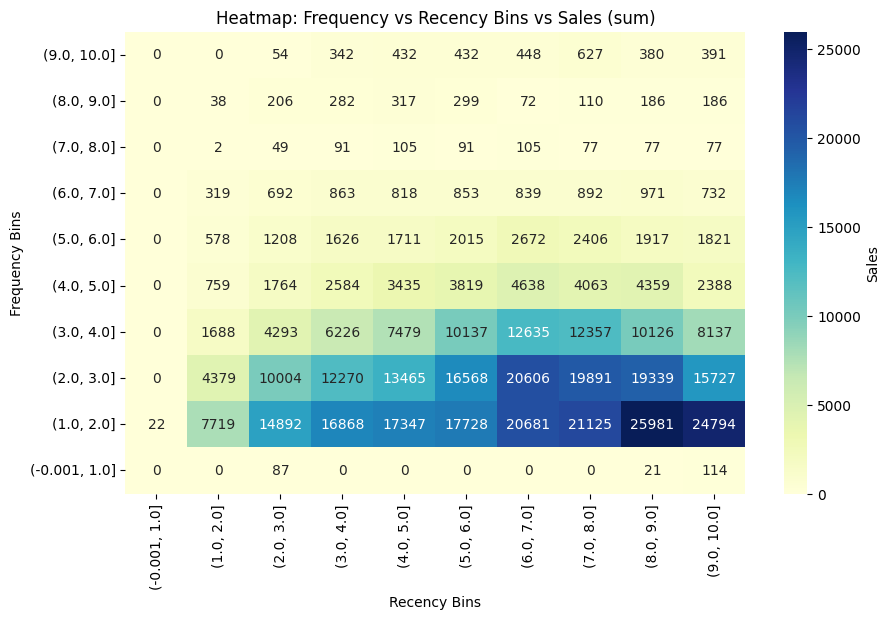

In [57]:
bins_recency = np.arange(0, 11, 1)  # 10 bins for Recency
bins_frequency = np.arange(0, 11, 1)  # 10 bins for Frequency

# Create binned columns
rf_data['Recency_bins'] = pd.cut(rf_data['Recency'], bins=bins_recency, include_lowest=True)
rf_data['Frequency_bins'] = pd.cut(rf_data['Frequency'], bins=bins_frequency, include_lowest=True)

# Assuming df is your dataframe
heatmap_data = rf_data.groupby(['Frequency_bins', 'Recency_bins'])['PRECIOOFERTA'].sum().unstack()

# Plotting the heatmap with flipped y-axis
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Sales'})
plt.title('Heatmap: Frequency vs Recency Bins vs Sales (sum)')
plt.xlabel('Recency Bins')
plt.ylabel('Frequency Bins')

# Invert the y-axis
plt.gca().invert_yaxis()

# Display the plot
plt.show()

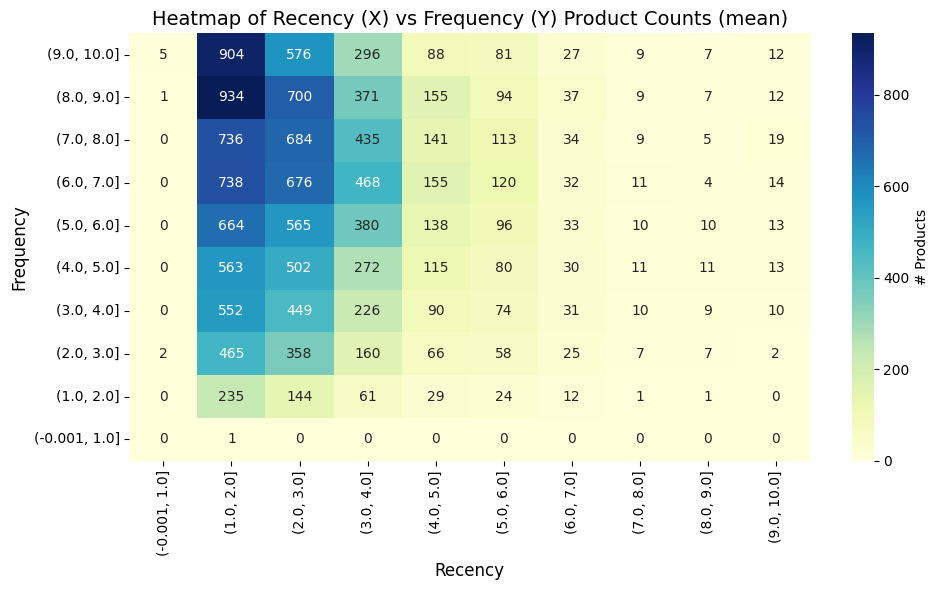

In [58]:
import seaborn as sns

# Aggregate product_count by Recency_bins and Frequency_bins
heatmap_data = cc_df.pivot_table(values='Product_Count', 
                              index='Recency_bins', 
                              columns='Frequency_bins', 
                              aggfunc='sum', fill_value=0)

# Plot heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': '# Products'})
plt.gca().invert_yaxis()  # Invert the y-axis for consistency

plt.title('Heatmap of Recency (X) vs Frequency (Y) Product Counts (mean)', fontsize=14)
plt.xlabel('Recency', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

In [42]:
cc_df.head

<bound method NDFrame.head of        Recency_bins Frequency_bins               Category  Product_Count
0     (-0.001, 1.0]  (-0.001, 1.0]  ACCESORIOS COSMETICOS              0
1     (-0.001, 1.0]  (-0.001, 1.0]             BIJOUTERIE              0
2     (-0.001, 1.0]  (-0.001, 1.0]           COMPLEMENTOS              0
3     (-0.001, 1.0]  (-0.001, 1.0]       CUIDADO PERSONAL              0
4     (-0.001, 1.0]  (-0.001, 1.0]             FRAGANCIAS              0
...             ...            ...                    ...            ...
1395    (9.0, 10.0]    (9.0, 10.0]     PROMOCION USUARIOS              0
1396    (9.0, 10.0]    (9.0, 10.0]                RELOJES              0
1397    (9.0, 10.0]    (9.0, 10.0]   TRATAMIENTO CORPORAL              0
1398    (9.0, 10.0]    (9.0, 10.0]     TRATAMIENTO FACIAL              0
1399    (9.0, 10.0]    (9.0, 10.0]                 VARIOS              0

[1400 rows x 4 columns]>